# 11. Concentration response

[5. Hits and effects](05_hits_and_effects.ipynb) asked whether a treatment moved. This page asks how much of it
was needed, which is a different design and a different set of traps:

- Most compounds never plateau inside the tested range, so a four-parameter logistic has no EC50 to find.
- Distance from the controls rises when a compound kills cells, which is not the same finding as a phenotype.
- A dose series usually spends its wells on concentrations rather than replicates, so any single concentration is
  thinly measured and the evidence lives in the shape across them.

The dataset is [the OASIS pilot](../datasets/oasis_pilot.ipynb): 36 compounds over ten concentrations, in two
cell lines.

In [1]:
import matplotlib.pyplot as plt
import numpy as np
import pandas as pd
import scanpy as sc

import mantispy as mt

adata = mt.ds.oasis_pilot()
# EMPTY wells hold no compound and no vehicle, so they are neither treatment nor control.
adata = adata[adata.obs["Metadata_Compound"].astype(str) != "EMPTY"].copy()
heparg = adata[adata.obs["Metadata_CellLine"] == "HepaRG"].copy()
heparg

/Users/tim.treis/Library/Application Support/hatch/env/virtual/mantispy/IN9GYQN4/tutorials/lib/python3.12/site-packages/tqdm/auto.py:21: TqdmWarning: IProgress not found. Please update jupyter and ipywidgets. See https://ipywidgets.readthedocs.io/en/stable/user_install.html
  from .autonotebook import tqdm as notebook_tqdm


AnnData object with n_obs × n_vars = 2831 × 99
    obs: 'Metadata_plate_map_name', 'Metadata_Plate', 'Metadata_Well', 'Metadata_Site_Count', 'Metadata_Count_Cells', 'Metadata_Count_CellsIncludingEdges', 'Metadata_Count_Cytoplasm', 'Metadata_Count_Nuclei', 'Metadata_Count_NucleiIncludingEdges', 'Metadata_Object_Count', 'Metadata_CellCount', 'Metadata_SiteCount', 'Metadata_Compound', 'Metadata_Concentration', 'Metadata_CellLine', 'Metadata_Control', 'Metadata_Perturbation'
    var: 'object', 'feature_group', 'feature', 'channel', 'scale', 'angle', 'gray_levels', 'radial_bin', 'params', 'is_feature'
    uns: 'mantispy'
    layers: None (.X)

## The usual preparation

Nothing here is specific to dose response: normalize each plate against its own controls, drop the features with
no spread among those controls, then select features.

In [2]:
mt.pp.normalize(heparg, by="Metadata_Plate", reference="negcon")
heparg = heparg[:, ~heparg.var["degenerate_scale"].to_numpy(dtype=bool)].copy()
mt.pp.feature_select(heparg, na_cutoff=0.0)
heparg = mt.pp.subset_features(heparg)
print(f"{heparg.n_obs} wells, {heparg.n_vars} features kept")

2831 wells, 99 features kept


## A mantispy object is an AnnData object

Nothing stops scanpy from working on it, which is the point of the format. The PCA, the neighbour graph and the
UMAP come from scanpy; the colours come from the columns `mt.ds.oasis_pilot` attached.

/var/folders/qg/qgc908995g3fc8qtss2fsbhhxyxxj4/T/ipykernel_23000/992733786.py:7: UserWarning: This figure includes Axes that are not compatible with tight_layout, so results might be incorrect.
  plt.tight_layout()


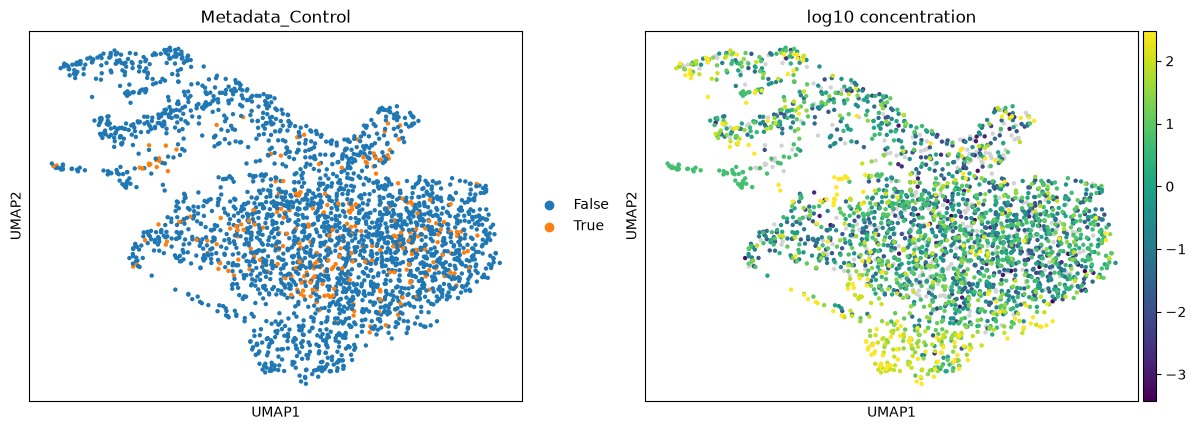

In [3]:
sc.pp.pca(heparg, n_comps=20)
sc.pp.neighbors(heparg)
sc.tl.umap(heparg)

heparg.obs["log10 concentration"] = np.log10(heparg.obs["Metadata_Concentration"].replace(0, np.nan))
sc.pl.umap(heparg, color=["Metadata_Control", "log10 concentration"], size=40, ncols=2, show=False)
plt.tight_layout()

The controls sit together and the highest concentrations sit furthest from them, which is what a dose series
should look like before any statistics are run.

## From profiles to a response per well

{func}`~mantispy.tl.hit_calling` writes two columns. `hits_distance` is the group's statistic repeated over its
rows; `hits_row_distance` is each well's own distance from the control centroid. The curve fit needs the second,
because a column that is constant within a group carries no dose information at all.

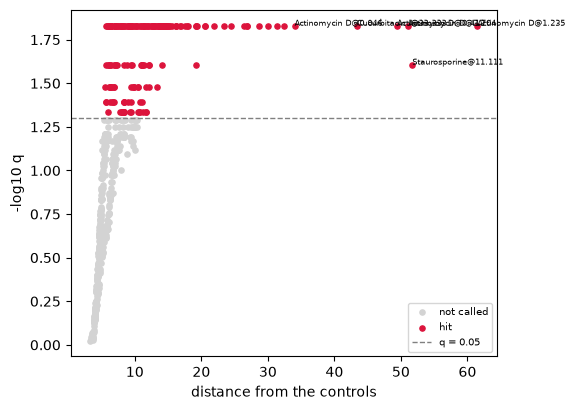

In [4]:
mt.tl.hit_calling(heparg, groupby="Metadata_Perturbation", use_rep="X_pca", n_permutations=300)
ax = mt.pl.hits(heparg, label_top=6)
plt.show()

That warning is worth reading rather than dismissing. Nearly every compound-at-a-concentration here sits in one
or two wells, so the per-group hit call is thin. This is the trade the plate map made: concentrations instead of
replicates. It is also why the next step is a curve rather than a table of per-concentration tests — a fit reads
all ten concentrations together, and the shape across them is what carries the evidence.

## Fitting the concentration response

In [5]:
mt.tl.dose_response(heparg, compound_key="Metadata_Compound", dose_key="Metadata_Concentration", min_doses=4)
curves = heparg.uns["mantispy"]["dose_response"].set_index("compound")
curves = curves[curves.index.astype(str) != "DMSO"]
curves.sort_values("hitcall", ascending=False).head(8)[
    ["n_doses", "spearman", "qvalue", "ec50", "r_squared", "fit_ok", "hitcall", "hitcall_model"]
]

,n_doses,spearman,qvalue,ec50,r_squared,fit_ok,hitcall,hitcall_model
compound,,,,,,,,
Staurosporine,10,0.598735,4.160661e-08,2.392436e-01,0.131876,False,1.000000,linear
Actinomycin D,10,0.435906,9.290771e-05,1.002241e+02,0.106392,False,0.999999,logistic
Fluazinam,10,0.578382,1.346795e-07,1.972634e+01,0.378007,False,0.999996,logistic
FCCP,10,0.669596,3.118984e-10,2.197888e+08,0.622103,False,0.999995,linear
"5,8,11-Eicosatriynoic acid",10,0.387472,5.972081e-04,2.016777e+07,0.481170,False,0.999994,linear
"5,6-benzoflavone",10,0.511855,3.266517e-06,3.829078e+01,0.614839,False,0.999992,logistic
Cucurbitacin I,10,0.515813,3.031965e-06,3.522260e+01,0.171159,False,0.999991,linear
CLIOQUINOL,10,0.604766,3.966933e-08,7.560326e+01,0.544926,False,0.999986,logistic


Three columns answer three different questions, and they disagree on purpose.

`spearman` with its `qvalue` asks whether the response rises with dose at all. It assumes no shape and works with
three points.

`fit_ok` asks whether the logistic converged on something curve-shaped with an EC50 inside the tested range. On
this screen it is `False` for most compounds, and that is honest: a compound still climbing at the top
concentration has no EC50 in range, so no potency should be quoted for it.

`hitcall` asks the screener's question, whether the response is large next to the noise the controls carry. It is
the product of three confidences from the ToxCast pipeline: that the curve beats a flat fit, that some
concentration's median clears the cutoff, and that the fitted top clears it. The cutoff is three times the
controls' MAD unless you pass one. `hitcall_model` names the shape that won: `logistic` where the curve
plateaus, `linear` where it is still climbing.

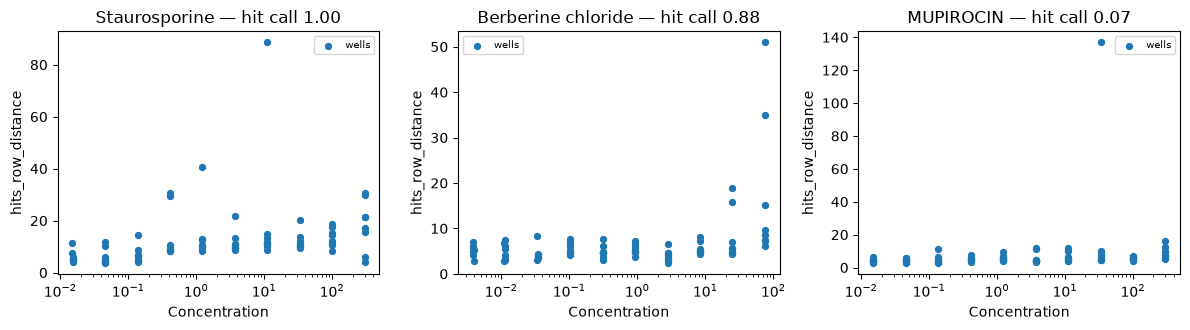

In [6]:
fig, axes = plt.subplots(1, 3, figsize=(12, 3.4))
for ax, compound in zip(axes, ["Staurosporine", "Berberine chloride", "MUPIROCIN"], strict=False):
    mt.pl.dose_response(heparg, compound=compound, ax=ax)
    ax.set_title(f"{compound} — hit call {curves['hitcall'].get(compound, float('nan')):.2f}")
fig.tight_layout()

Staurosporine inhibits kinases broadly and climbs far past the band. Mupirocin inhibits a bacterial enzyme and
has no target in a human cell, so it never leaves it. Berberine barely leaves it either in this cell line, and
the last section says why that is worth checking rather than resolving here.

## Which features move, and at what concentration

The curve above reads one number per well, its distance from the controls. That number says a compound did
something; it cannot say what. {func}`~mantispy.tl.dose_features` asks the same question of every feature and
reports, for each one, the lowest concentration at which its median response reaches three times the spread the
controls show on it.

That is a benchmark dose rather than an EC50, and the difference matters here. An EC50 needs a plateau, and the
section above showed most compounds never reach one inside the tested range. A benchmark dose only needs the
response to cross a line the controls set, so it is defined for a feature that is still climbing at the top
concentration, which is most of them. The ToxCast pipeline reads its `3 * bmad` the same way.

In [7]:
mt.tl.dose_features(heparg)
features = heparg.uns["mantispy"]["dose_features"]
# bmd is NaN for a feature that never crosses the cutoff, so dropna leaves the ones that responded.
active = features[features["compound"] == "Staurosporine"].dropna(subset=["bmd"])
print(f"{len(active)} of {features['feature'].nunique()} features respond to staurosporine")
active.sort_values("bmd").head(8)[["feature", "bmd", "max_z", "direction", "spearman", "qvalue"]]

30 of 99 features respond to staurosporine


,feature,bmd,max_z,direction,spearman,qvalue
920,Cytoplasm_AreaShape_Zernike_1_1,0.336446,3.445138,1.0,0.066715,0.655931
926,Cytoplasm_AreaShape_Zernike_6_2,0.362584,4.209308,1.0,0.313785,0.012627
963,Nuclei_Correlation_Overlap_AGP_DNA,0.368756,3.983743,-1.0,-0.218047,0.099024
923,Cytoplasm_AreaShape_Zernike_5_1,0.397345,4.653107,1.0,0.313973,0.012627
893,Cells_AreaShape_Zernike_2_0,0.452776,3.777016,1.0,0.300500,0.017164
971,Nuclei_RadialDistribution_FracAtD_DNA_3of4,0.467828,5.298065,1.0,0.518075,0.000017
925,Cytoplasm_AreaShape_Zernike_6_0,0.760535,3.965238,1.0,0.296635,0.018215
947,Cytoplasm_RadialDistribution_MeanFrac_Brightfi...,0.788329,3.821740,-1.0,-0.559913,0.000002


The first features to move do so at a few hundred nanomolar, and they are measurements of shape and of where
intensity sits rather than how much of it there is: Zernike moments of the cytoplasm, and how far out in the
nucleus the DNA stain lies.

`spearman` and `bmd` disagree in the first row, which is worth understanding rather than averaging away. A
monotonic trend across the whole range and a threshold crossing are different questions. A feature that steps up
early and then flattens has a low Spearman and a low benchmark dose; a feature that rises steadily to a small
final value has a high Spearman and no benchmark dose at all. Read both, and treat a crossing with no trend
behind it as the weakest kind of evidence.

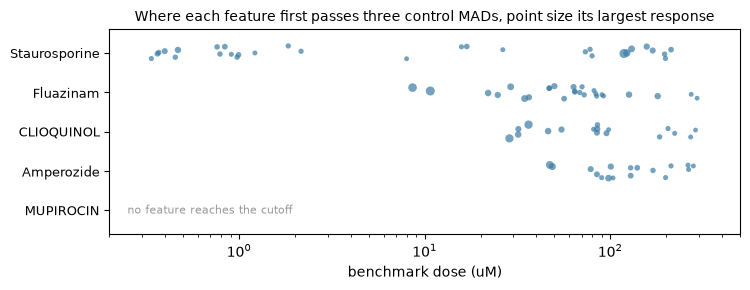

In [8]:
shown = ["MUPIROCIN", "Amperozide", "CLIOQUINOL", "Fluazinam", "Staurosporine"]
jitter = np.random.default_rng(0)

fig, ax = plt.subplots(figsize=(7.6, 3.0))
for row, compound in enumerate(shown):
    block = features[features["compound"] == compound].dropna(subset=["bmd"])
    if block.empty:
        ax.text(0.25, row, "no feature reaches the cutoff", fontsize=8, va="center", color="#999999")
        continue
    ax.scatter(
        block["bmd"],
        row + jitter.uniform(-0.18, 0.18, len(block)),
        s=4 * block["max_z"],
        color="#3a7ca5",
        alpha=0.7,
        edgecolor="none",
    )
ax.set_xscale("log")
ax.set_xlim(0.2, 500)
ax.set_ylim(-0.6, len(shown) - 0.4)
ax.set_xlabel("benchmark dose (uM)")
ax.set_yticks(range(len(shown)), shown, fontsize=9)
ax.set_title("Where each feature first passes three control MADs, point size its largest response", fontsize=10)
fig.tight_layout()

The potencies separate by three orders of magnitude: staurosporine moves a feature at 0.34 uM, fluazinam at 8.6,
clioquinol at 29, amperozide at 47. Mupirocin moves none of the 99, which is the calibration this plot needs — a
compound with no target in a human cell should not cross a control-derived cutoff anywhere.

The feature names repeat across compounds, though. `Nuclei_Correlation_Correlation_Brightfield_DNA` and
`Cells_Correlation_Overlap_DNA_Mito` are among the first five of amperozide, clioquinol and fluazinam alike; for
staurosporine they are twenty-first and ninth. Either those two are what a stressed cell does whatever the
mechanism, or they are simply the features this plate measures most sensitively. Either way a list of responsive
features per compound is not yet a claim that the compounds do different things, and the count of them is not a
measure of how much happened.

## The same phenotype, or a different one?

A distance from the controls grows for two reasons that matter differently: the same phenotype gets stronger, or a
different phenotype takes over. A distance cannot tell them apart, because it throws the direction away.

{func}`~mantispy.tl.dose_direction` keeps it. Each concentration gets `amplitude`, how far its median profile sits
from the controls in MADs per feature; `split_half_cosine`, the cosine between the directions the two halves of
its replicate plates point in; and `cosine_to_top`, the cosine against the highest concentration's profile.
`amplitude_null` is what control wells spread over the same plates in the same numbers reach, so the first column
has a floor.

The three only mean anything together. A concentration whose plate halves disagree has no direction at all,
however large its amplitude. One whose halves agree but which points away from the top concentration is a real
phenotype, and a different one.

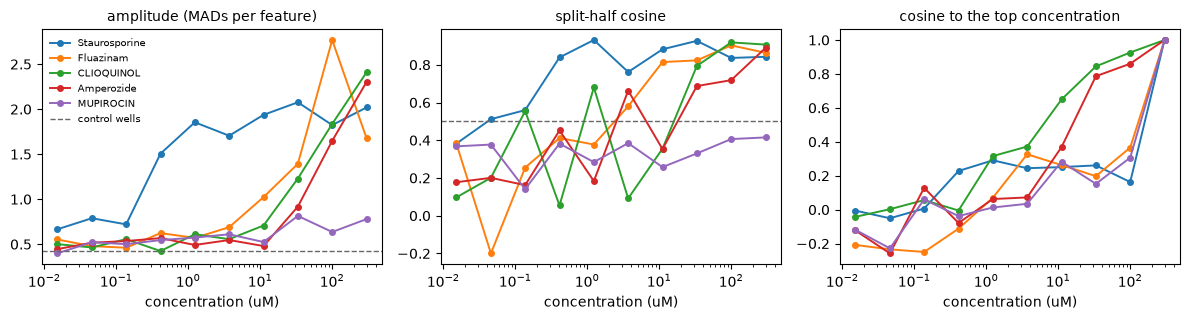

In [9]:
mt.tl.dose_direction(heparg)
direction = heparg.uns["mantispy"]["dose_direction"]

fig, axes = plt.subplots(1, 3, figsize=(12, 3.3), sharex=True)
for compound in shown[::-1]:
    block = direction[direction["compound"] == compound].sort_values("dose")
    for ax, column in zip(axes, ["amplitude", "split_half_cosine", "cosine_to_top"], strict=True):
        ax.plot(block["dose"], block[column], marker="o", ms=4, lw=1.4, label=compound)

axes[0].axhline(direction["amplitude_null"].median(), ls="--", lw=1, color="0.4", label="control wells")
axes[1].axhline(0.5, ls="--", lw=1, color="0.4")
titles = ["amplitude (MADs per feature)", "split-half cosine", "cosine to the top concentration"]
for ax, title in zip(axes, titles, strict=True):
    ax.set_xscale("log")
    ax.set_xlabel("concentration (uM)")
    ax.set_title(title, fontsize=10)
axes[0].legend(fontsize=7, frameon=False)
fig.tight_layout()

Four compounds, four shapes.

Amperozide and clioquinol are the straightforward case. Nothing happens below about 30 uM — amplitude at the
control floor, plate halves disagreeing — and then the amplitude climbs to 2.3 and 2.4 MADs per feature while
`cosine_to_top` climbs with it, to 0.86 and 0.93 at 100 uM. One phenotype, arriving late and getting louder. For
these two a single number per concentration loses nothing.

Staurosporine is the case a single number hides. Its amplitude reaches 1.5 at 0.41 uM and then stops: 1.9 at
1.2 uM, 2.1 at 33, 2.0 at 300. Read as a distance it saturates two decades below the top of the range, and the
curve fitted earlier says the same. But the plate halves agree from 0.41 uM on, 0.76 and above, so every one of
those concentrations has a direction that reproduces — and `cosine_to_top` stays between 0.16 and 0.29. The cell
is doing something different at 0.41 uM than at 300 uM. The distance stopped moving at exactly the concentration
the phenotype started changing, which is why no summary built on distance alone can see this.

Fluazinam never settles. Its halves agree from 11 uM up, yet `cosine_to_top` stays at or below 0.37 the whole way,
and its amplitude falls from 2.8 to 1.7 between 100 and 300 uM. Something else happens in the top well; this page
does not establish what, and the cytotoxicity below is the first thing to check.

Mupirocin is the floor: amplitude between 0.40 and 0.81 against a null of 0.42, and no concentration whose halves
agree above 0.41. Its 33 uM well reaches nearly twice the null amplitude and still has no direction, which is the
reason to read the two columns together rather than putting a threshold on the first.

## Distance is not the same as phenotype

A compound that kills cells also moves away from the controls, and the curve cannot tell the two apart.
{func}`~mantispy.tl.cytotoxicity` compares each group's cells per field against the controls', so the calls can
be read beside it.

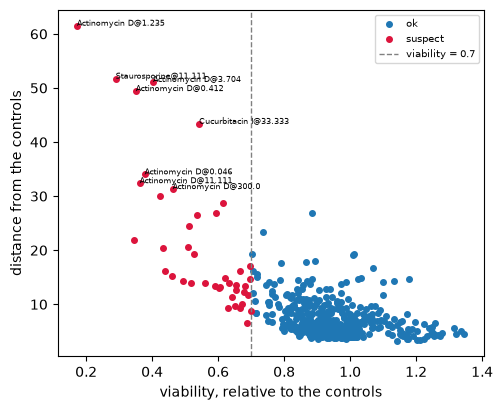

In [10]:
mt.tl.cytotoxicity(heparg, groupby="Metadata_Perturbation")
ax = mt.pl.cytotoxicity(heparg)
plt.show()

A high call with viability near one is a change in the shape of living cells. A high call with viability
collapsed is the morphology of dying cells, which most mechanisms share. The US EPA's phenotypic profiling
pipeline drops any concentration that loses more than half the cells before it fits anything, and that is a
reasonable habit here.

## Does the call survive a second cell line?

The same compounds were dosed in U2OS. The two lines were normalized and feature-selected apart, so their
distances are not on one scale, but their calls can still be compared.

/var/folders/qg/qgc908995g3fc8qtss2fsbhhxyxxj4/T/ipykernel_23000/2041206685.py:7: UserWarning: 280 of 289 groups have fewer than three rows, so their statistic is the median of one or two wells. Aggregate more replicates, or score activity with mt.tl.map(mode='activity'), which ranks replicate pairs and is built for screens with little replication.
  mt.tl.hit_calling(u2os, groupby="Metadata_Perturbation", use_rep="X_pca", n_permutations=300)


28 shared compounds, 64% called the same way in both


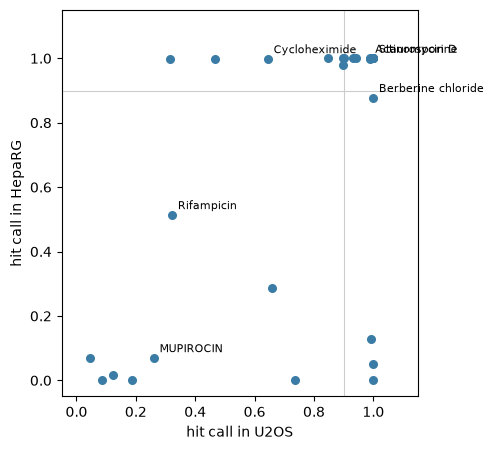

In [11]:
u2os = adata[adata.obs["Metadata_CellLine"] == "U2OS"].copy()
mt.pp.normalize(u2os, by="Metadata_Plate", reference="negcon")
u2os = u2os[:, ~u2os.var["degenerate_scale"].to_numpy(dtype=bool)].copy()
mt.pp.feature_select(u2os, na_cutoff=0.0)
u2os = mt.pp.subset_features(u2os)
sc.pp.pca(u2os, n_comps=20)
mt.tl.hit_calling(u2os, groupby="Metadata_Perturbation", use_rep="X_pca", n_permutations=300)
mt.tl.dose_response(u2os, compound_key="Metadata_Compound", dose_key="Metadata_Concentration", min_doses=4)

other = u2os.uns["mantispy"]["dose_response"].set_index("compound")
both = pd.DataFrame({"U2OS": other["hitcall"], "HepaRG": curves["hitcall"]}).dropna()

fig, ax = plt.subplots(figsize=(5, 4.6))
ax.scatter(both["U2OS"], both["HepaRG"], s=30, color="#3a7ca5", zorder=3)
for compound in ["Staurosporine", "Actinomycin D", "Cycloheximide", "MUPIROCIN", "Rifampicin", "Berberine chloride"]:
    if compound in both.index:
        ax.annotate(
            compound,
            (both.loc[compound, "U2OS"], both.loc[compound, "HepaRG"]),
            fontsize=8,
            xytext=(4, 4),
            textcoords="offset points",
        )
ax.axvline(0.9, color="0.8", lw=0.8, zorder=0)
ax.axhline(0.9, color="0.8", lw=0.8, zorder=0)
ax.set(xlabel="hit call in U2OS", ylabel="hit call in HepaRG", xlim=(-0.05, 1.15), ylim=(-0.05, 1.15))
print(
    f"{len(both)} shared compounds, "
    f"{((both['U2OS'] >= 0.9) == (both['HepaRG'] >= 0.9)).mean():.0%} called the same way in both"
)
fig.tight_layout()

The corners carry the biology. Staurosporine and actinomycin D inhibit kinases and transcription, and are called
in both lines. Mupirocin and rifampicin are antibacterials with no mammalian target, and are called in neither.
Cycloheximide and berberine sit off the diagonal, the first called in HepaRG and the second in U2OS, which is a
statement about two cell types rather than a failure of the fit.

## Summary

- Use `hits_row_distance` as the response, not `hits_distance`. The group column is one number repeated over its
  wells.
- `fit_ok` and `hitcall` answer different questions. Quote an EC50 only when `fit_ok` is `True`; use `hitcall` to
  decide whether anything happened at all.
- The cutoff comes from the controls, so a screen with few or drifting controls gives a hit call you should not
  trust. {func}`~mantispy.pp.well_qc` and
  [8. Trustworthy features and design](08_trustworthy_features_and_design.ipynb) come first.
- Read every call beside a cell count.
- A call that holds in a second cell line is worth more than a small q-value in one.
- Read the features, not only the distance. {func}`~mantispy.tl.dose_features` gives each one a benchmark dose,
  which is defined for a feature still climbing at the top concentration, where an EC50 is not.
- A distance that plateaus does not mean the phenotype stopped changing.
  {func}`~mantispy.tl.dose_direction` separates one phenotype getting louder from a second one taking over.
- Amplitude alone overcalls. Mupirocin's 33 uM well sits at nearly twice the control floor with no direction that
  reproduces across plates.
